In [8]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tabulate import tabulate

    - Function to format results into a table

In [9]:
# Custom function to display tables in a formatted way
def display_table(df: pd.DataFrame, title: str):
    """
    Display a formatted table for quick analysis and validation of results.

    Parameters
    ----------
    df (pd.DataFrame): DataFrame to be displayed.
    title (str): Title printed above the table.


    Returns
    -------
    df (pd.DataFrame)
    """

    print(f"\n{title}")
    if df is None:
        print("⚠️ No data provided.")
        return

    if isinstance(df, pd.Series):
        df = df.to_frame()

    if not isinstance(df, pd.DataFrame):
        print("⚠️ Invalid data format.")
        return

    if df.empty or df.shape[1] == 0:
        print("⚠️ No valid data or columns not found.")
        return

    colalign = ["center"] * len(df.columns)
    print(tabulate(df, headers="keys", tablefmt="fancy_grid", colalign=colalign, showindex=True, floatfmt=".8f"))

---

In [10]:
# Base directory where LSTM results were saved
cache_dir = Path(r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\Tese_LSTM_results")

# LSTM test result folders
LSTM_paths = {"LSTM Naive": cache_dir / "Tese_Bitcoin_Naive_test_rolling_step10_h120_pkl",
              "LSTM Original": cache_dir / "Tese_Bitcoin_Variance_ret(L)_LSTM_test_rolling_step10_h120_pkl",
              "LSTM Logarithmic": cache_dir / "Tese_Bitcoin_Log-Variance_ret(L)_LSTM_test_rolling_step10_h120_pkl",
              "LSTM Yeo-Johnson": cache_dir / "Tese_Bitcoin_Yeo-Johnson-Variance_ret(L)_LSTM_test_rolling_step10_h120_pkl"}

In [11]:
# Function to load LSTM test results
def load_lstm_test_result(model_name: str, folder_path: Path):
    """
    Load LSTM test_results.parquet from a saved cache folder
    and add the model name.
    """

    test_file = folder_path / "test_results.parquet"

    if not test_file.exists():
        raise FileNotFoundError(f"File not found: {test_file}")

    df = pd.read_parquet(test_file).copy()
    df.insert(0, "Model", model_name)

    return df

In [12]:
# Load all LSTM test results
lstm_test_frames = []

for model_name, folder_path in LSTM_paths.items():
    df_tmp = load_lstm_test_result(model_name, folder_path)
    lstm_test_frames.append(df_tmp)

df_lstm_all = pd.concat(lstm_test_frames, ignore_index=True)

df_lstm_compare_clean = df_lstm_all.copy()

# Standardise model names, if needed
df_lstm_compare_clean["Model"] = (df_lstm_compare_clean["Model"].astype(str).replace({"LSTM Naive": "Naive","LSTM Original": "Original",
                                                                                      "LSTM Logarithmic": "Logarithmic",
                                                                                      "LSTM Yeo-Johnson": "Yeo-Johnson",
                                                                                      "lstm Naive": "Naive",
                                                                                      "lstm Original": "Original",
                                                                                      "lstm Logarithmic": "Logarithmic",
                                                                                      "lstm Yeo-Johnson": "Yeo-Johnson"}))

# Drop unnecessary benchmark-specific columns, if present
cols_to_drop = ["model", "variant", "m", "score_selected"]
df_lstm_compare_clean = df_lstm_compare_clean.drop(columns=cols_to_drop, errors="ignore")

# LSTM configuration columns
config_cols = ["lookback",
               "n_units",
               "n_layers",
               "dropout",
               "recurrent_dropout",
               "dense_units",
               "learning_rate",
               "batch_size",
               "epochs",
               "loss",
               "optimizer",
               "output_size"]

# Ensure all LSTM configuration columns exist
for col in config_cols:
    if col not in df_lstm_compare_clean.columns:
        df_lstm_compare_clean[col] = np.nan

# Format integer hyperparameters without decimal places
int_config_cols = ["lookback", "n_units", "n_layers", "batch_size", "epochs", "output_size"]

for col in int_config_cols:
    if col in df_lstm_compare_clean.columns:
        df_lstm_compare_clean[col] = df_lstm_compare_clean[col].apply(lambda x: int(x) if pd.notna(x) and x != "-" else x)

# Replace missing LSTM configuration values with "-"
for col in config_cols:
    df_lstm_compare_clean[col] = (df_lstm_compare_clean[col].astype(object).where(df_lstm_compare_clean[col].notna(), "-"))

# Optional: replace explicit None/nan strings with "-"
for col in config_cols:
    df_lstm_compare_clean[col] = (df_lstm_compare_clean[col].astype(str).replace({"None": "-", "nan": "-", "<NA>": "-"}))

# Set Model as index
df_lstm_compare_clean = df_lstm_compare_clean.set_index("Model")

# Order columns: LSTM configuration first, then metrics
metric_cols = [c for c in df_lstm_compare_clean.columns if c not in config_cols]

df_lstm_compare_clean = df_lstm_compare_clean[config_cols + metric_cols]

display_table(df_lstm_compare_clean, "Loaded LSTM test results - cleaned")


Loaded LSTM test results - cleaned
╒═════════════╤════════════╤═══════════╤════════════╤═══════════╤═════════════════════╤═══════════════╤═════════════════╤══════════════╤══════════╤════════╤═════════════╤═══════════════╤════════════╤════════════╤═════════════╤═════════════╤══════════════╤═════════════════╤═══════════════════╤════════════════╤════════════════╤════════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═══════════════╤═══════════════════╤═══════════════════╤════════════════════╤════════════════════╤═══════════════════════╤═════════════════╤══════════════════╕
│    Model    │  lookback  │  n_units  │  n_layers  │  dropout  │  recurrent_dropout  │  dense_units  │  learning_rate  │  batch_size  │  epochs  │  loss  │  optimizer  │  output_size  │  RMSE-h=1  │  RMSE-h=7  │  RMSE-h=15  │  RMSE-h=30  │  RMSE-h=120  │    MAPE-h=1     │     MAPE-h=7      │   MAPE-h=15    │   MAPE-h=30  

In [13]:
# Select RMSE columns
rmse_cols = sorted([c for c in df_lstm_all.columns if c.startswith("RMSE-h=")], key=lambda x: int(x.split("=")[1]))

# Build clean comparison table
df_lstm_rmse_compare = df_lstm_all[["Model"] + rmse_cols + ["score_rmse_mean"] + ["score_qlike_mean"]].copy()

# Rename columns for thesis-style display
rename_cols = {"RMSE-h=1": "h=1", "RMSE-h=7": "h=7", "RMSE-h=15": "h=15", "RMSE-h=30": "h=30", "RMSE-h=120": "h=120", "score_rmse_mean": "Mean RMSE", "score_qlike_mean": "Mean QLIKE"}

df_lstm_rmse_compare = df_lstm_rmse_compare.rename(columns=rename_cols)

# Set model as index
df_lstm_rmse_compare = df_lstm_rmse_compare.set_index("Model")

display_table(df_lstm_rmse_compare, "Comparative test performance of lstm specifications across volatility-proxy representations")


Comparative test performance of lstm specifications across volatility-proxy representations
╒══════════════════╤════════════╤════════════╤════════════╤════════════╤════════════╤═════════════╤══════════════╕
│      Model       │    h=1     │    h=7     │    h=15    │    h=30    │   h=120    │  Mean RMSE  │   Mean QLIKE │
╞══════════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═════════════╪══════════════╡
│    LSTM Naive    │ 0.00102799 │ 0.00088119 │ 0.00075977 │ 0.00086042 │ 0.00090332 │ 0.00088654  │ 361.79743534 │
├──────────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼─────────────┼──────────────┤
│  LSTM Original   │ 0.00120244 │ 0.00104232 │ 0.00110518 │ 0.00104182 │ 0.00102897 │ 0.00108415  │  -6.17766902 │
├──────────────────┼────────────┼────────────┼────────────┼────────────┼────────────┼─────────────┼──────────────┤
│ LSTM Logarithmic │ 0.00077183 │ 0.00043292 │ 0.00058252 │ 0.00059075 │ 0.00058577 │ 0.00059276  │  -

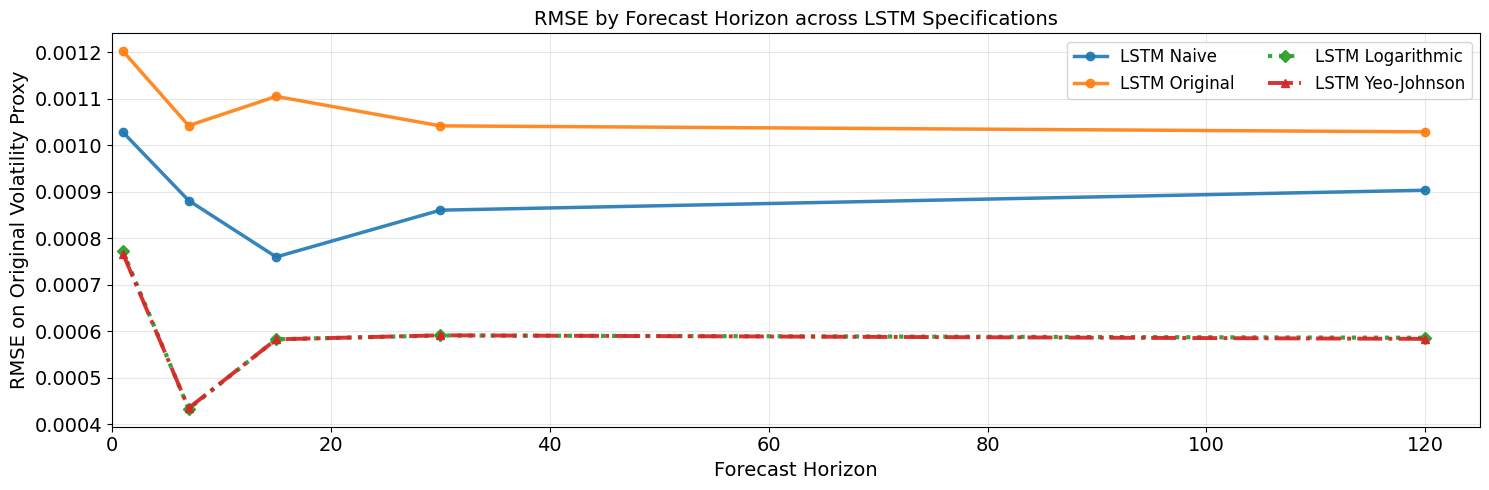

In [14]:
# Plot RMSE by forecast horizon for LSTM specifications and Naive benchmark
def plot_lstm_specifications_rmse(df_compare: pd.DataFrame):
    """
    Plot RMSE by forecast horizon for LSTM specifications and Naive benchmark.
    """

    horizon_cols = [c for c in df_compare.columns if c.startswith("h=")]
    horizons = [int(c.split("=")[1]) for c in horizon_cols]

    plt.figure(figsize=(15, 5))

    plot_styles = {"Naive": {"marker": "o", "linestyle": "--", "linewidth": 2.5, "alpha": 0.9, "zorder": 1},
                   "LSTM": {"marker": "s", "linestyle": "-", "linewidth": 2.2, "alpha": 0.9, "zorder": 3},
                   "LSTM Logarithmic": {"marker": "D", "linestyle": ":", "linewidth": 3.0, "alpha": 0.95, "zorder": 4},
                   "LSTM Yeo-Johnson": {"marker": "^", "linestyle": "-.", "linewidth": 2.8, "alpha": 0.95, "zorder": 5}}

    for model_name in df_compare.index:
        rmse_values = df_compare.loc[model_name, horizon_cols].astype(float).values

        style = plot_styles.get(model_name, {"marker": "o", "linestyle": "-", "linewidth": 2.5, "alpha": 0.9, "zorder": 2})

        plt.plot(horizons, rmse_values, label=model_name, marker=style["marker"], linestyle=style["linestyle"], linewidth=style["linewidth"],
                 alpha=style["alpha"], zorder=style["zorder"])

    plt.title("RMSE by Forecast Horizon across LSTM Specifications", fontsize=14)
    plt.xlabel("Forecast Horizon", fontsize=14)
    plt.ylabel("RMSE on Original Volatility Proxy", fontsize=14)

    # X-axis like the reference plot
    plt.xticks(np.arange(0, 121, 20), fontsize=14)
    plt.xlim(0, 125)

    plt.yticks(fontsize=14)

    # Legend with two columns
    plt.legend(fontsize=12, loc="upper right", ncol=2, frameon=True)

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_lstm_specifications_rmse(df_lstm_rmse_compare)